# 03 - Evaluación de Métricas del Modelo

Evaluamos el rendimiento del modelo entrenado usando métricas estándar de clasificación.

**Modelo entrenado con 25 intents** para el chatbot de Los Motes de la Magdalena.

## ¿Qué métricas calcularemos?
- **Accuracy**: Porcentaje general de predicciones correctas
- **Precision**: De todas las predicciones de una clase, ¿cuántas fueron correctas?
- **Recall**: De todos los ejemplos reales de una clase, ¿cuántos identificó el modelo?
- **F1-Score**: Media armónica de precision y recall (balance entre ambas)
- **Matriz de Confusión**: Visualización de errores entre clases
- **Balance de Clases**: Distribución de ejemplos por intent
- **Top-K Accuracy**: Si la predicción correcta está en las K más probables
- **Confianza por Intent**: Qué tan seguro está el modelo en cada clasificación

## 1. Importar librerías

Usamos sklearn para calcular métricas y seaborn/matplotlib para visualizaciones.

In [30]:
import spacy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 2. Cargar el modelo entrenado

Cargamos el modelo guardado en la carpeta `models/intent_classifier/`.

In [31]:
# Cargar modelo entrenado
model_path = Path("../models/intent_classifier")
nlp = spacy.load(model_path)

# Obtener las etiquetas del modelo
all_labels = list(nlp.get_pipe("textcat_multilabel").labels)

print(f"✅ Modelo cargado desde: {model_path}")
print(f"📋 Pipeline: {nlp.pipe_names}")
print(f"🏷️ Etiquetas ({len(all_labels)}): {sorted(all_labels)}")

✅ Modelo cargado desde: ..\models\intent_classifier
📋 Pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'textcat_multilabel']
🏷️ Etiquetas (25): ['agradecimiento', 'app_movil', 'cancelar_pedido', 'confirmar_pedido', 'consultar_horario', 'consultar_menu', 'consultar_precio', 'consultar_ubicacion', 'correccion_direccion', 'datos_factura', 'delivery', 'despedida', 'fallback', 'hablar_humano', 'info_empresa', 'metodos_pago', 'modificar_pedido', 'opinion_comida', 'queja', 'realizar_pedido', 'reservacion', 'retiro_local', 'saludo', 'seguimiento_pedido', 'trabajo']


## 3. Cargar datos de evaluación

Usamos los mismos datos de `intents.jsonl` y recreamos la división train/test con la misma semilla para obtener el mismo conjunto de validación.

In [32]:
# Cargar datos
data = []
with open('../data/intents.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

# Extraer textos y etiquetas
texts = [item['text'] for item in data]
labels = [item['label'] for item in data]

# Dividir con la misma semilla que en entrenamiento
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"📊 Datos cargados:")
print(f"   Total: {len(data)} ejemplos")
print(f"   Validación: {len(val_texts)} ejemplos")
print(f"   Intents únicos: {len(set(labels))}")

📊 Datos cargados:
   Total: 612 ejemplos
   Validación: 123 ejemplos
   Intents únicos: 25


## 3.1 Balance de Clases

Verificamos cuántos ejemplos tiene cada intent en el dataset.
Un desbalance muy grande puede afectar el rendimiento en clases minoritarias.

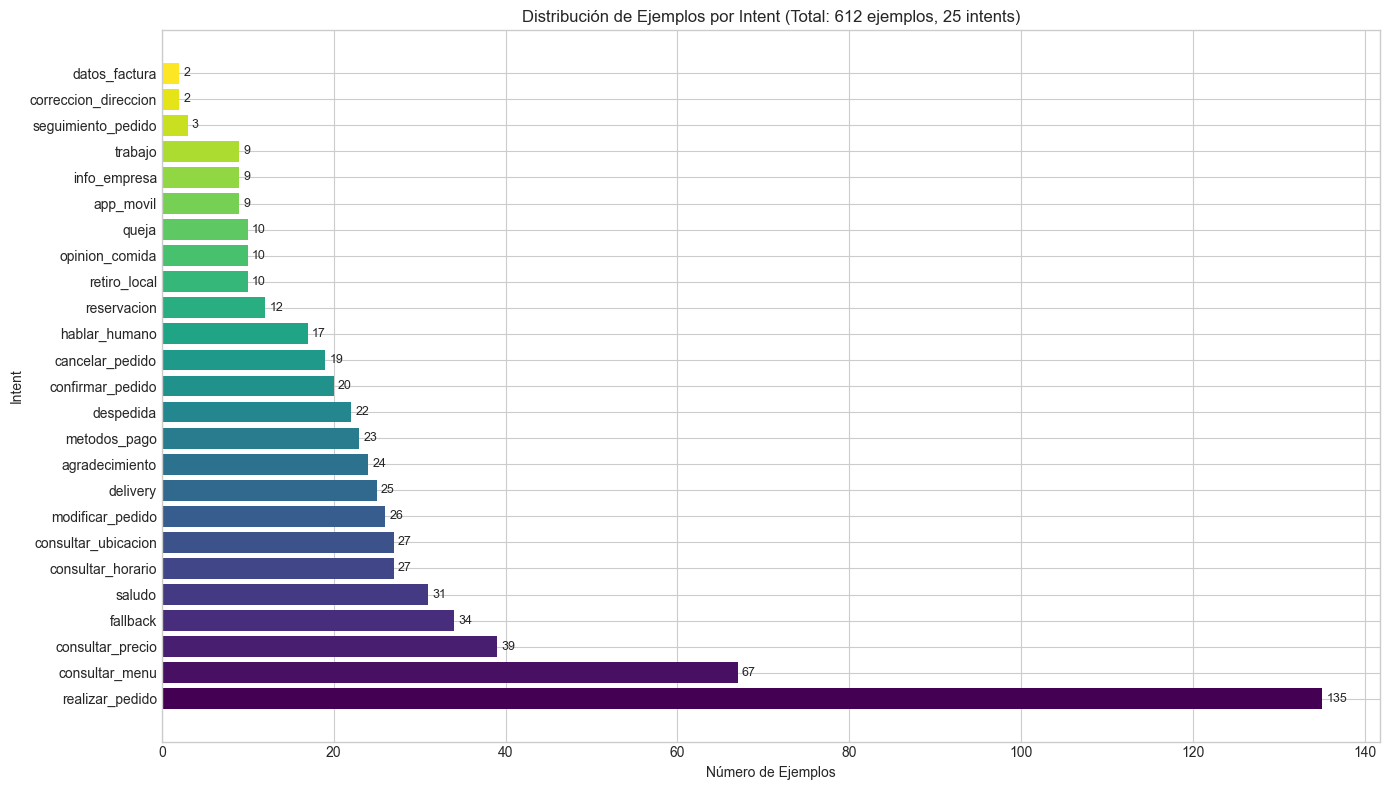


📊 ESTADÍSTICAS DE BALANCE DE CLASES
   Total de intents: 25
   Total de ejemplos: 612
   Promedio ejemplos/intent: 24.5
   Mínimo ejemplos: 2 (correccion_direccion)
   Máximo ejemplos: 135 (realizar_pedido)

⚠️ Intents con menos de 5 ejemplos (pueden tener bajo rendimiento):
   - correccion_direccion: 2 ejemplos
   - seguimiento_pedido: 3 ejemplos
   - datos_factura: 2 ejemplos


In [34]:
# Contar ejemplos por intent
from collections import Counter
label_counts = Counter(labels)
label_counts_sorted = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

# Visualizar distribución
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(label_counts_sorted)))
bars = ax.barh(list(label_counts_sorted.keys()), list(label_counts_sorted.values()), color=colors)

# Agregar valores
for bar, val in zip(bars, label_counts_sorted.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

ax.set_xlabel('Número de Ejemplos')
ax.set_ylabel('Intent')
ax.set_title(f'Distribución de Ejemplos por Intent (Total: {len(data)} ejemplos, {len(label_counts)} intents)')
plt.tight_layout()
plt.show()

# Estadísticas de balance
print(f"\n📊 ESTADÍSTICAS DE BALANCE DE CLASES")
print(f"   Total de intents: {len(label_counts)}")
print(f"   Total de ejemplos: {len(data)}")
print(f"   Promedio ejemplos/intent: {len(data)/len(label_counts):.1f}")
print(f"   Mínimo ejemplos: {min(label_counts.values())} ({min(label_counts, key=label_counts.get)})")
print(f"   Máximo ejemplos: {max(label_counts.values())} ({max(label_counts, key=label_counts.get)})")

# Identificar clases con pocos ejemplos
MIN_EXAMPLES = 5
low_examples = {k: v for k, v in label_counts.items() if v < MIN_EXAMPLES}
if low_examples:
    print(f"\n⚠️ Intents con menos de {MIN_EXAMPLES} ejemplos (pueden tener bajo rendimiento):")
    for intent, count in low_examples.items():
        print(f"   - {intent}: {count} ejemplos")

## 4. Generar predicciones

Pasamos todos los textos de validación por el modelo y obtenemos las predicciones.

In [35]:
# Generar predicciones para el conjunto de validación
y_true = val_labels  # Etiquetas reales
y_pred = []          # Predicciones del modelo
y_conf = []          # Confianza de cada predicción

for text in val_texts:
    doc = nlp(text)
    # Obtener la categoría con mayor probabilidad
    predicted = max(doc.cats, key=doc.cats.get)
    confidence = doc.cats[predicted]
    y_pred.append(predicted)
    y_conf.append(confidence)

print(f"✅ Predicciones generadas: {len(y_pred)}")
print(f"📊 Confianza promedio: {np.mean(y_conf):.2%}")
print(f"📊 Confianza mínima: {np.min(y_conf):.2%}")
print(f"📊 Confianza máxima: {np.max(y_conf):.2%}")

✅ Predicciones generadas: 123
📊 Confianza promedio: 74.09%
📊 Confianza mínima: 0.04%
📊 Confianza máxima: 100.00%


## 5. Métricas Generales

Calculamos las métricas globales del modelo:
- **Accuracy**: % de predicciones correctas del total
- **Precision (macro)**: Promedio de precision por clase
- **Recall (macro)**: Promedio de recall por clase  
- **F1-Score (macro)**: Promedio de F1 por clase

In [36]:
# Calcular métricas generales
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("=" * 50)
print("📊 MÉTRICAS GENERALES DEL MODELO")
print("=" * 50)
print(f"\n   Accuracy:  {accuracy:.2%}")
print(f"   Precision: {precision:.2%}")
print(f"   Recall:    {recall:.2%}")
print(f"   F1-Score:  {f1:.2%}")
print("=" * 50)

# Interpretación
if accuracy >= 0.90:
    print("\n✅ Excelente rendimiento (>90%)")
elif accuracy >= 0.80:
    print("\n✅ Buen rendimiento (80-90%)")
elif accuracy >= 0.70:
    print("\n⚠️ Rendimiento aceptable (70-80%)")
else:
    print("\n❌ Rendimiento bajo (<70%) - se recomienda más datos")

📊 MÉTRICAS GENERALES DEL MODELO

   Accuracy:  69.11%
   Precision: 47.85%
   Recall:    48.32%
   F1-Score:  46.77%

❌ Rendimiento bajo (<70%) - se recomienda más datos


## 6. Reporte de Clasificación por Intent

Mostramos precision, recall y F1 para **cada intent** individualmente.
Esto ayuda a identificar qué clases tienen problemas.

In [37]:
# Reporte de clasificación detallado
print("📋 REPORTE DE CLASIFICACIÓN POR INTENT")
print("=" * 70)
print(classification_report(y_true, y_pred, zero_division=0))

📋 REPORTE DE CLASIFICACIÓN POR INTENT
                     precision    recall  f1-score   support

     agradecimiento       0.75      0.60      0.67         5
          app_movil       0.00      0.00      0.00         2
    cancelar_pedido       0.67      1.00      0.80         4
   confirmar_pedido       0.80      1.00      0.89         4
  consultar_horario       0.00      0.00      0.00         6
     consultar_menu       0.65      0.93      0.76        14
   consultar_precio       0.89      1.00      0.94         8
consultar_ubicacion       0.60      0.60      0.60         5
           delivery       0.30      0.60      0.40         5
          despedida       1.00      0.75      0.86         4
           fallback       0.57      0.57      0.57         7
      hablar_humano       0.33      0.33      0.33         3
       info_empresa       0.00      0.00      0.00         2
       metodos_pago       0.83      1.00      0.91         5
   modificar_pedido       1.00      0.60      

## 7. Visualización de Métricas por Intent

Un gráfico de barras que muestra F1-Score de cada intent.
Las barras rojas indican intents con bajo rendimiento (F1 < 0.7).

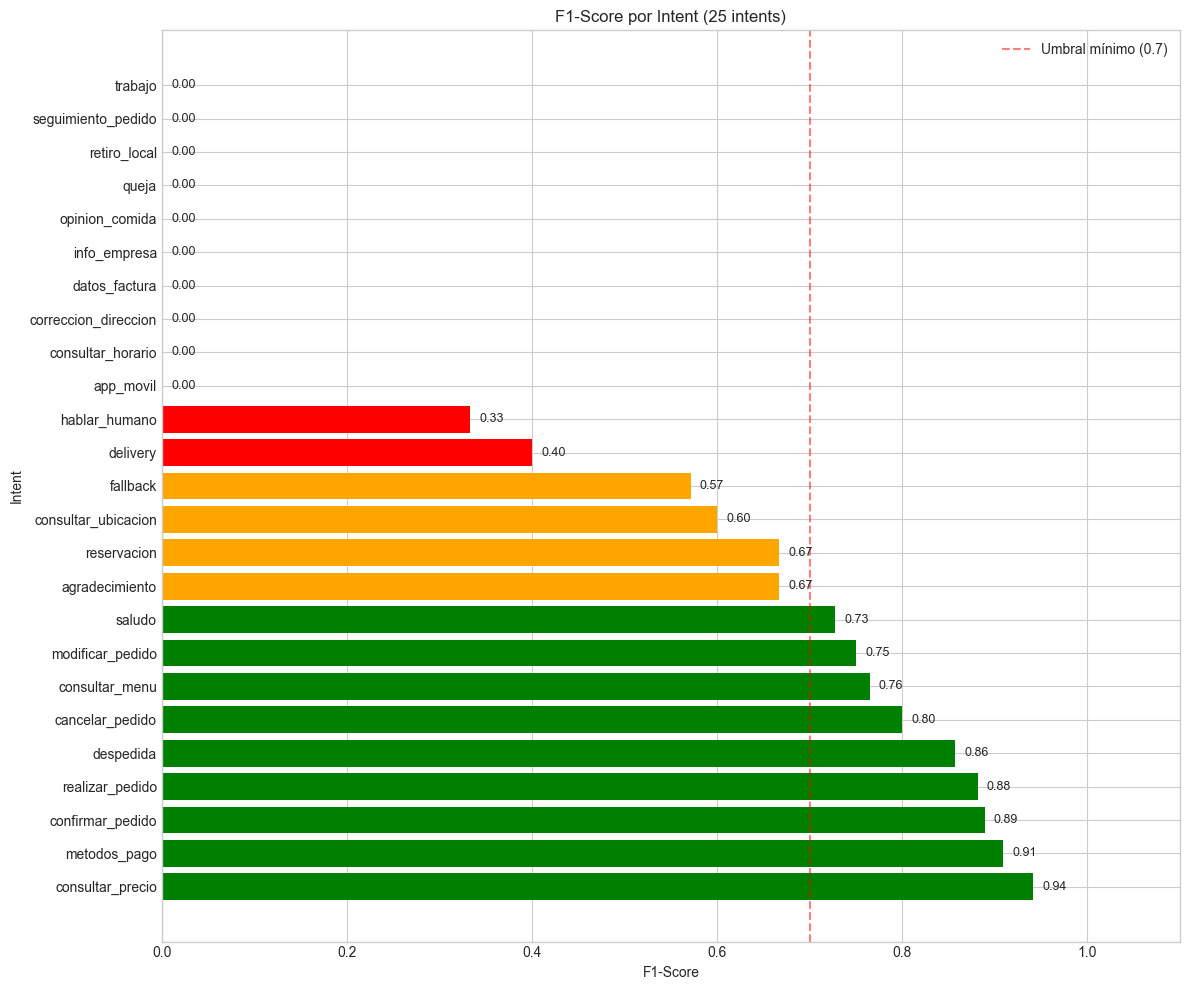


⚠️ Intents con F1 < 0.7 (necesitan más ejemplos):
   - agradecimiento: 0.67
   - reservacion: 0.67
   - consultar_ubicacion: 0.60
   - fallback: 0.57
   - delivery: 0.40
   - hablar_humano: 0.33
   - app_movil: 0.00
   - consultar_horario: 0.00
   - correccion_direccion: 0.00
   - datos_factura: 0.00
   - info_empresa: 0.00
   - opinion_comida: 0.00
   - queja: 0.00
   - retiro_local: 0.00
   - seguimiento_pedido: 0.00
   - trabajo: 0.00


In [38]:
# Calcular F1 por clase
from sklearn.metrics import f1_score as f1_per_class

# Usar todas las etiquetas del modelo (25 intents)
unique_labels = sorted(all_labels)

# Calcular F1 para cada clase
f1_per_intent = {}
for label in unique_labels:
    y_true_binary = [1 if y == label else 0 for y in y_true]
    y_pred_binary = [1 if y == label else 0 for y in y_pred]
    f1_per_intent[label] = f1_score(y_true_binary, y_pred_binary, zero_division=0)

# Ordenar por F1 score
f1_sorted = dict(sorted(f1_per_intent.items(), key=lambda x: x[1], reverse=True))

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['green' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in f1_sorted.values()]
bars = ax.barh(list(f1_sorted.keys()), list(f1_sorted.values()), color=colors)

# Agregar línea de umbral
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Umbral mínimo (0.7)')

# Agregar valores
for bar, val in zip(bars, f1_sorted.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('F1-Score')
ax.set_ylabel('Intent')
ax.set_title(f'F1-Score por Intent ({len(unique_labels)} intents)')
ax.set_xlim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

# Identificar intents problemáticos
intents_bajos = {k: v for k, v in f1_sorted.items() if v < 0.7}
if intents_bajos:
    print(f"\n⚠️ Intents con F1 < 0.7 (necesitan más ejemplos):")
    for intent, score in intents_bajos.items():
        print(f"   - {intent}: {score:.2f}")
else:
    print(f"\n✅ Todos los {len(unique_labels)} intents tienen F1 >= 0.7")

## 8. Matriz de Confusión

La matriz de confusión muestra qué intents se confunden entre sí:
- **Diagonal**: Predicciones correctas (queremos valores altos aquí)
- **Fuera de diagonal**: Confusiones (errores del modelo)

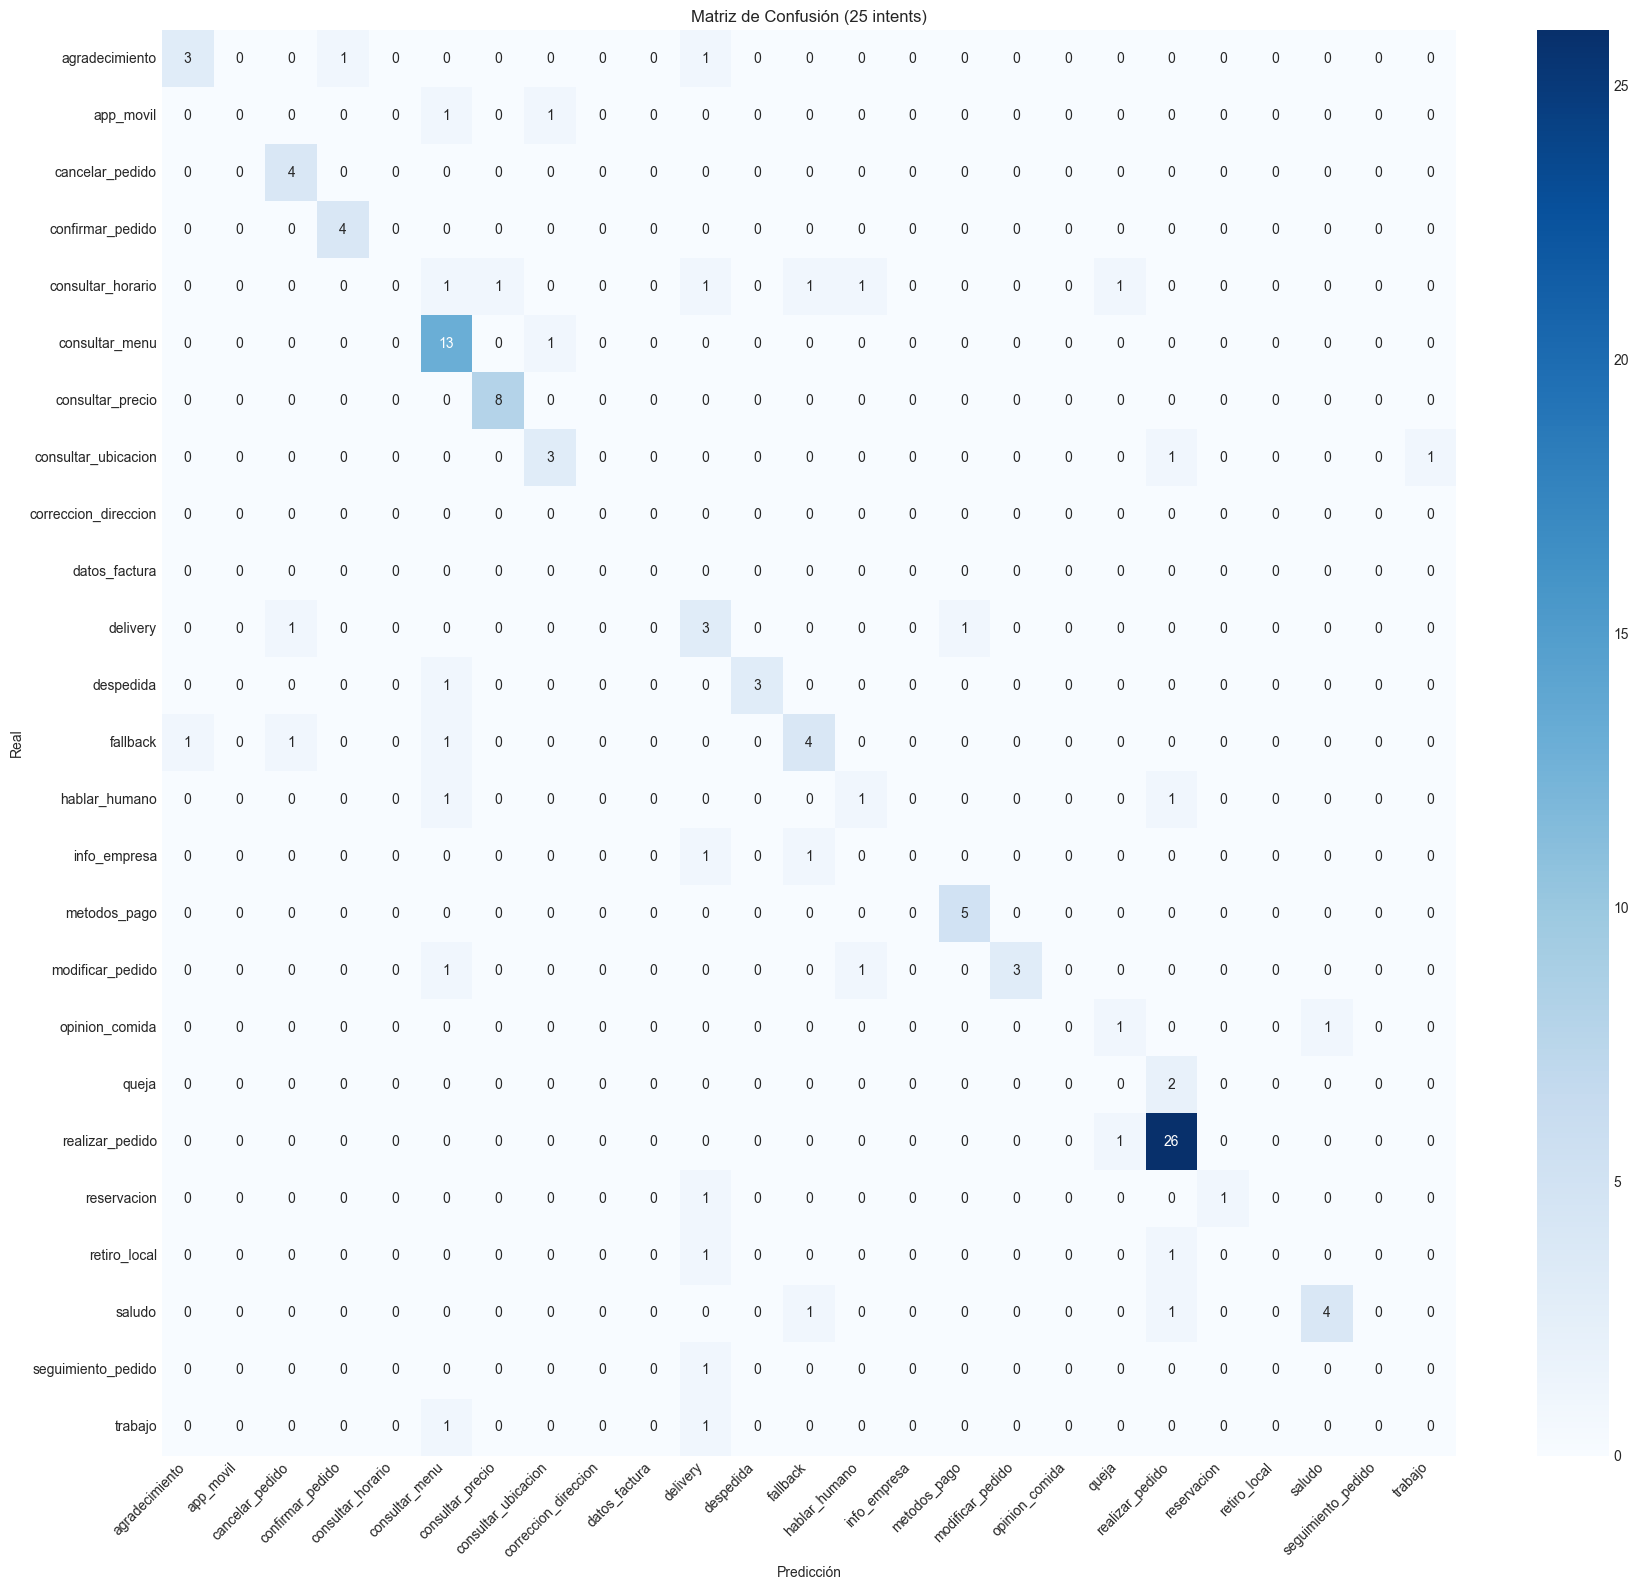

📊 Matriz de confusión: 25x25


In [39]:
# Calcular matriz de confusión (usando los 25 intents del modelo)
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

# Crear heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, yticklabels=unique_labels, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión ({len(unique_labels)} intents)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"📊 Matriz de confusión: {len(unique_labels)}x{len(unique_labels)}")

## 9. Análisis de Confusiones Frecuentes

Identificamos los pares de intents que más se confunden entre sí.

In [40]:
# Encontrar confusiones (errores fuera de la diagonal)
confusions = []
for i, true_label in enumerate(unique_labels):
    for j, pred_label in enumerate(unique_labels):
        if i != j and cm[i, j] > 0:  # Fuera de diagonal y con errores
            confusions.append({
                'real': true_label,
                'predicho': pred_label,
                'errores': cm[i, j]
            })

# Ordenar por número de errores
confusions_df = pd.DataFrame(confusions).sort_values('errores', ascending=False)

if len(confusions_df) > 0:
    print("❌ CONFUSIONES MÁS FRECUENTES")
    print("=" * 60)
    print("\nCuando el intent real es X, el modelo predice Y:\n")
    for _, row in confusions_df.head(10).iterrows():
        print(f"   {row['real']} → {row['predicho']}: {row['errores']} error(es)")
else:
    print("✅ ¡No hay confusiones! El modelo clasifica perfectamente.")

❌ CONFUSIONES MÁS FRECUENTES

Cuando el intent real es X, el modelo predice Y:

   queja → realizar_pedido: 2 error(es)
   agradecimiento → delivery: 1 error(es)
   app_movil → consultar_menu: 1 error(es)
   app_movil → consultar_ubicacion: 1 error(es)
   agradecimiento → confirmar_pedido: 1 error(es)
   consultar_horario → consultar_menu: 1 error(es)
   consultar_horario → consultar_precio: 1 error(es)
   consultar_horario → fallback: 1 error(es)
   consultar_horario → delivery: 1 error(es)
   consultar_horario → queja: 1 error(es)


## 10. Distribución de Confianza del Modelo

Analizamos qué tan "seguro" está el modelo de sus predicciones.
- **Alta confianza** (>0.8): El modelo está muy seguro
- **Baja confianza** (<0.5): El modelo tiene dudas

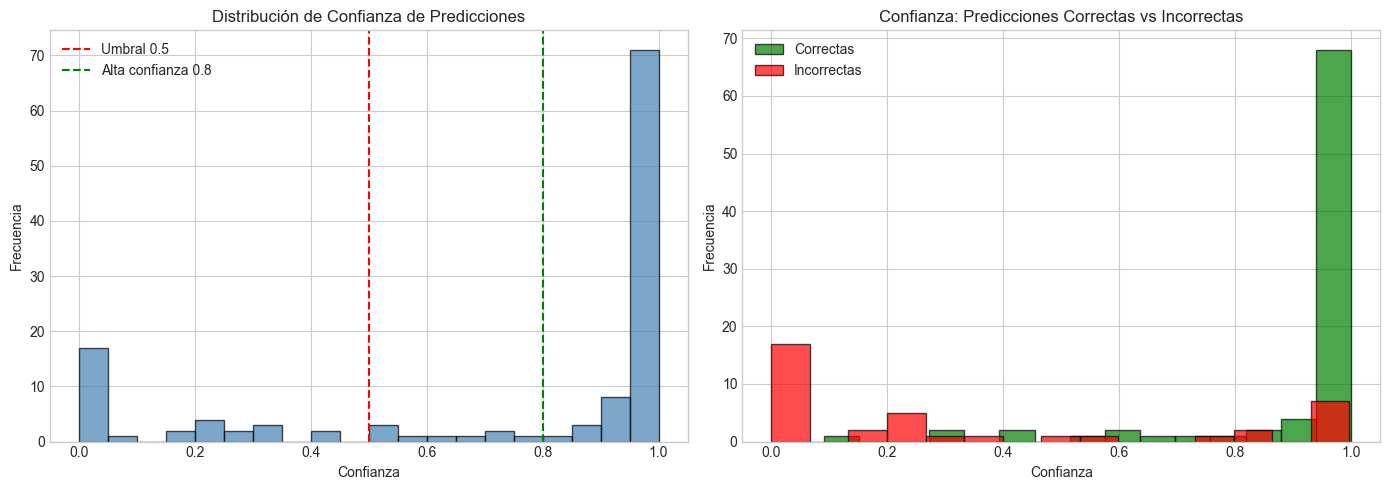

📊 ESTADÍSTICAS DE CONFIANZA
   Confianza promedio: 74.09%
   Confianza mínima: 0.04%
   Confianza máxima: 100.00%
   Predicciones con confianza < 50%: 31
   Predicciones con confianza > 80%: 83


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma general de confianza
axes[0].hist(y_conf, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[0].axvline(x=0.8, color='green', linestyle='--', label='Alta confianza 0.8')
axes[0].set_xlabel('Confianza')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Confianza de Predicciones')
axes[0].legend()

# Confianza correctos vs incorrectos
correct_mask = [t == p for t, p in zip(y_true, y_pred)]
conf_correct = [c for c, m in zip(y_conf, correct_mask) if m]
conf_incorrect = [c for c, m in zip(y_conf, correct_mask) if not m]

axes[1].hist(conf_correct, bins=15, alpha=0.7, label='Correctas', color='green', edgecolor='black')
axes[1].hist(conf_incorrect, bins=15, alpha=0.7, label='Incorrectas', color='red', edgecolor='black')
axes[1].set_xlabel('Confianza')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Confianza: Predicciones Correctas vs Incorrectas')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas de confianza
print(f"📊 ESTADÍSTICAS DE CONFIANZA")
print(f"   Confianza promedio: {np.mean(y_conf):.2%}")
print(f"   Confianza mínima: {np.min(y_conf):.2%}")
print(f"   Confianza máxima: {np.max(y_conf):.2%}")
print(f"   Predicciones con confianza < 50%: {sum(1 for c in y_conf if c < 0.5)}")
print(f"   Predicciones con confianza > 80%: {sum(1 for c in y_conf if c > 0.8)}")

## 11. Análisis de Predicciones Incorrectas

Revisamos ejemplos específicos donde el modelo se equivocó para entender sus debilidades.

In [42]:
# Crear DataFrame con predicciones incorrectas
errors = []
for i, (text, true, pred, conf) in enumerate(zip(val_texts, y_true, y_pred, y_conf)):
    if true != pred:
        errors.append({
            'texto': text[:80] + '...' if len(text) > 80 else text,
            'real': true,
            'predicho': pred,
            'confianza': f"{conf:.1%}"
        })

errors_df = pd.DataFrame(errors)

if len(errors_df) > 0:
    print(f"❌ PREDICCIONES INCORRECTAS ({len(errors_df)} errores)")
    print("=" * 100)
    display(errors_df)
else:
    print("✅ ¡No hay errores! El modelo clasifica correctamente todos los ejemplos de prueba.")

❌ PREDICCIONES INCORRECTAS (38 errores)


,texto,real,predicho,confianza
0,se agradece,agradecimiento,delivery,0.4%
1,horario portal shopping,consultar_horario,queja,0.1%
2,agregar empanadas al pedido,modificar_pedido,consultar_menu,17.9%
3,es buena la fritada,opinion_comida,queja,25.6%
4,estan cerca del centro,consultar_ubicacion,trabajo,27.2%
5,thanks,agradecimiento,confirmar_pedido,1.9%
6,hi,saludo,fallback,93.2%
7,estan abiertos los sabados,consultar_horario,delivery,1.4%
8,trabajan con uber eats,delivery,metodos_pago,0.2%
9,quiero presentar una queja formal,queja,realizar_pedido,95.1%


## 12. Resumen Final y Recomendaciones

Basándonos en todas las métricas evaluadas, hacemos un diagnóstico del modelo.

In [43]:
# Diagnóstico automático basado en métricas
print("=" * 70)
print("📋 RESUMEN FINAL DEL MODELO")
print("=" * 70)

# Evaluar rendimiento general
if accuracy >= 0.9:
    print(f"\n✅ EXCELENTE: Accuracy de {accuracy:.1%}")
    print("   El modelo está listo para producción.")
elif accuracy >= 0.8:
    print(f"\n🟡 BUENO: Accuracy de {accuracy:.1%}")
    print("   El modelo es aceptable para producción con monitoreo.")
elif accuracy >= 0.7:
    print(f"\n🟠 REGULAR: Accuracy de {accuracy:.1%}")
    print("   Considera agregar más ejemplos de entrenamiento.")
else:
    print(f"\n🔴 BAJO: Accuracy de {accuracy:.1%}")
    print("   Se requiere mejorar significativamente el modelo.")

# Identificar intents problemáticos
print(f"\n📊 RESUMEN DE MÉTRICAS:")
print(f"   • Accuracy: {accuracy:.1%}")
print(f"   • Precision (macro): {precision:.1%}")
print(f"   • Recall (macro): {recall:.1%}")
print(f"   • F1-Score (macro): {f1:.1%}")

# Intents con bajo rendimiento (usando f1_per_intent calculado anteriormente)
low_f1_intents = {k: v for k, v in f1_per_intent.items() if v < 0.7}
if len(low_f1_intents) > 0:
    print(f"\n⚠️  INTENTS CON F1 < 70% (necesitan más ejemplos):")
    for intent, score in low_f1_intents.items():
        print(f"   • {intent}: {score:.1%}")
else:
    print(f"\n✅ Todos los intents tienen F1 ≥ 70%")

# Recomendaciones
print("\n💡 RECOMENDACIONES:")
recommendations = []
if accuracy < 0.85:
    recommendations.append("1. Agregar más ejemplos de entrenamiento")
if len(confusions_df) > 3:
    recommendations.append("2. Revisar intents muy similares que se confunden")
if np.mean(y_conf) < 0.7:
    recommendations.append("3. El modelo tiene baja confianza promedio, necesita más datos")

if recommendations:
    for r in recommendations:
        print(f"   {r}")
else:
    print("   ¡El modelo tiene buen rendimiento! Solo monitorear en producción.")

print("\n" + "=" * 70)
print("Modelo guardado en: ../models/intent_classifier/")
print("=" * 70)

📋 RESUMEN FINAL DEL MODELO

🔴 BAJO: Accuracy de 69.1%
   Se requiere mejorar significativamente el modelo.

📊 RESUMEN DE MÉTRICAS:
   • Accuracy: 69.1%
   • Precision (macro): 47.9%
   • Recall (macro): 48.3%
   • F1-Score (macro): 46.8%

⚠️  INTENTS CON F1 < 70% (necesitan más ejemplos):
   • agradecimiento: 66.7%
   • app_movil: 0.0%
   • consultar_horario: 0.0%
   • consultar_ubicacion: 60.0%
   • correccion_direccion: 0.0%
   • datos_factura: 0.0%
   • delivery: 40.0%
   • fallback: 57.1%
   • hablar_humano: 33.3%
   • info_empresa: 0.0%
   • opinion_comida: 0.0%
   • queja: 0.0%
   • reservacion: 66.7%
   • retiro_local: 0.0%
   • seguimiento_pedido: 0.0%
   • trabajo: 0.0%

💡 RECOMENDACIONES:
   1. Agregar más ejemplos de entrenamiento
   2. Revisar intents muy similares que se confunden

Modelo guardado en: ../models/intent_classifier/


## 13. Top-K Accuracy

Calculamos si la predicción correcta está entre las K más probables.
Útil cuando la primera predicción es incorrecta pero la segunda o tercera es correcta.

📊 TOP-K ACCURACY

   Top-1 Accuracy: 69.11% (85/123)
   Top-2 Accuracy: 74.80% (92/123)
   Top-3 Accuracy: 78.05% (96/123)


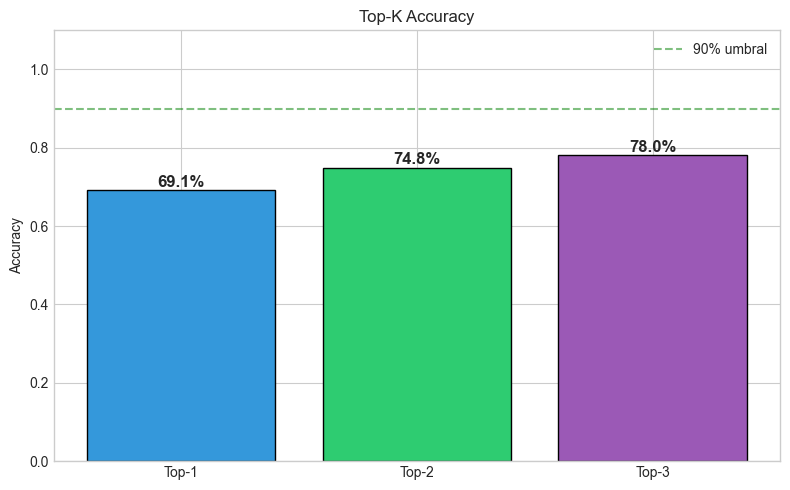


💡 Interpretación:
   - El 5.7% de errores se corrigen si consideramos la 2da opción
   - El 8.9% de errores se corrigen si consideramos las 3 primeras opciones


In [44]:
# Calcular Top-K accuracy
def get_top_k_predictions(text, nlp, k=3):
    """Retorna las K predicciones más probables"""
    doc = nlp(text)
    sorted_cats = sorted(doc.cats.items(), key=lambda x: x[1], reverse=True)
    return [cat for cat, _ in sorted_cats[:k]]

# Calcular Top-1, Top-2, Top-3 accuracy
top_1_correct = 0
top_2_correct = 0
top_3_correct = 0

for text, true_label in zip(val_texts, y_true):
    top_k = get_top_k_predictions(text, nlp, k=3)
    if true_label == top_k[0]:
        top_1_correct += 1
        top_2_correct += 1
        top_3_correct += 1
    elif len(top_k) > 1 and true_label == top_k[1]:
        top_2_correct += 1
        top_3_correct += 1
    elif len(top_k) > 2 and true_label == top_k[2]:
        top_3_correct += 1

total = len(val_texts)
top_1_acc = top_1_correct / total
top_2_acc = top_2_correct / total
top_3_acc = top_3_correct / total

print("📊 TOP-K ACCURACY")
print("=" * 50)
print(f"\n   Top-1 Accuracy: {top_1_acc:.2%} ({top_1_correct}/{total})")
print(f"   Top-2 Accuracy: {top_2_acc:.2%} ({top_2_correct}/{total})")
print(f"   Top-3 Accuracy: {top_3_acc:.2%} ({top_3_correct}/{total})")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
k_values = ['Top-1', 'Top-2', 'Top-3']
accuracies = [top_1_acc, top_2_acc, top_3_acc]
colors = ['#3498db', '#2ecc71', '#9b59b6']
bars = ax.bar(k_values, accuracies, color=colors, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy')
ax.set_title('Top-K Accuracy')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='90% umbral')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n💡 Interpretación:")
print(f"   - El {(top_2_acc - top_1_acc)*100:.1f}% de errores se corrigen si consideramos la 2da opción")
print(f"   - El {(top_3_acc - top_1_acc)*100:.1f}% de errores se corrigen si consideramos las 3 primeras opciones")

## 14. Confianza Promedio por Intent

Analizamos qué tan "seguro" está el modelo para cada intent.
Intents con baja confianza pueden necesitar más ejemplos o son ambiguos.

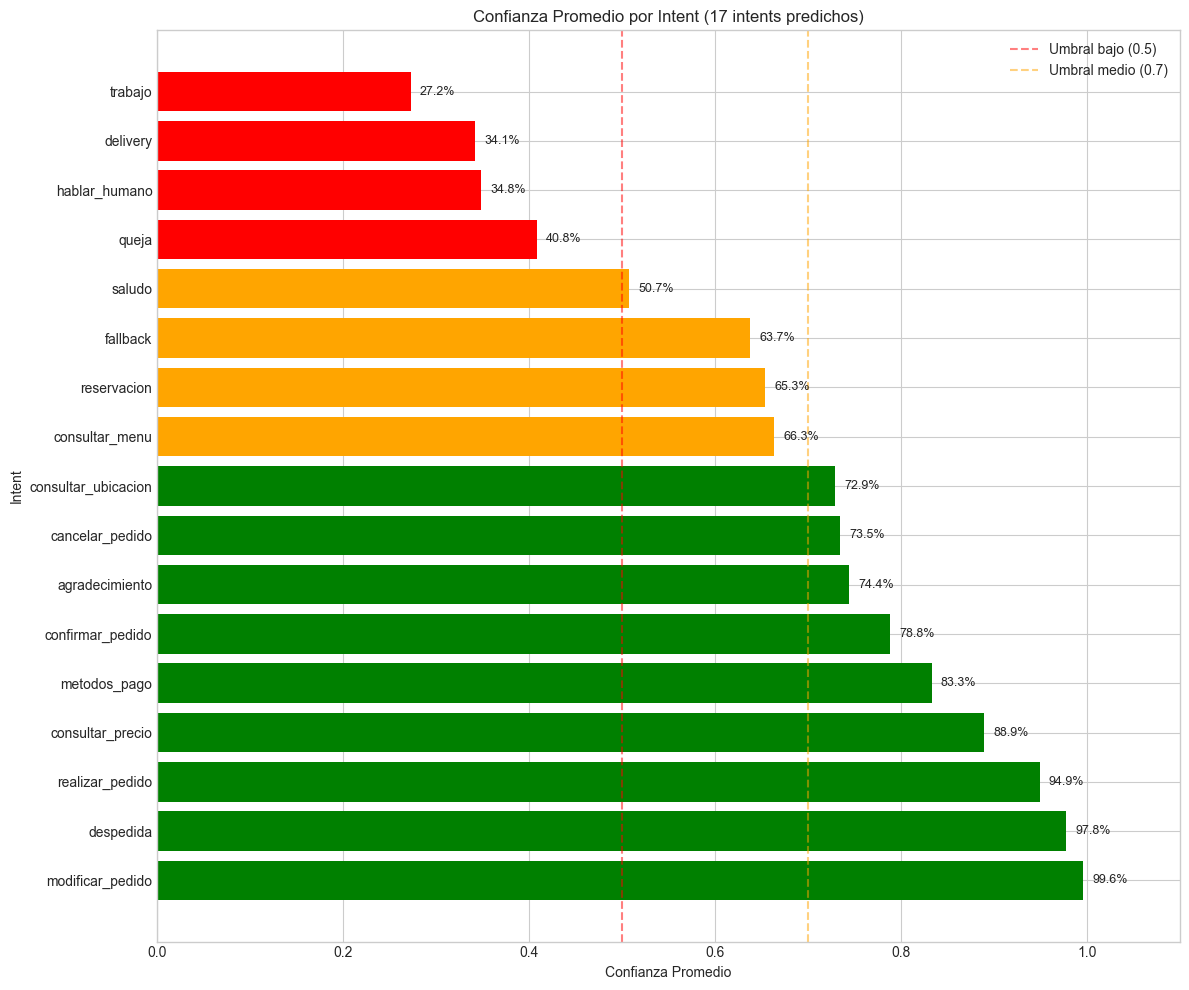


⚠️ Intents con confianza promedio < 60%:
   - saludo: 50.7%
   - queja: 40.8%
   - hablar_humano: 34.8%
   - delivery: 34.1%
   - trabajo: 27.2%

📝 Intents no predichos en validación (8):
   - app_movil
   - consultar_horario
   - correccion_direccion
   - datos_factura
   - info_empresa
   - opinion_comida
   - retiro_local
   - seguimiento_pedido


In [45]:
# Calcular confianza promedio por intent predicho
conf_by_intent = {}
for pred, conf in zip(y_pred, y_conf):
    if pred not in conf_by_intent:
        conf_by_intent[pred] = []
    conf_by_intent[pred].append(conf)

# Calcular promedio (solo intents que fueron predichos)
avg_conf_by_intent = {k: np.mean(v) for k, v in conf_by_intent.items()}
avg_conf_sorted = dict(sorted(avg_conf_by_intent.items(), key=lambda x: x[1], reverse=True))

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['green' if v >= 0.7 else 'orange' if v >= 0.5 else 'red' for v in avg_conf_sorted.values()]
bars = ax.barh(list(avg_conf_sorted.keys()), list(avg_conf_sorted.values()), color=colors)

# Agregar líneas de referencia
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Umbral bajo (0.5)')
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Umbral medio (0.7)')

# Agregar valores
for bar, val in zip(bars, avg_conf_sorted.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

ax.set_xlabel('Confianza Promedio')
ax.set_ylabel('Intent')
ax.set_title(f'Confianza Promedio por Intent ({len(avg_conf_sorted)} intents predichos)')
ax.set_xlim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

# Identificar intents con baja confianza
low_conf_intents = {k: v for k, v in avg_conf_sorted.items() if v < 0.6}
if low_conf_intents:
    print(f"\n⚠️ Intents con confianza promedio < 60%:")
    for intent, conf in low_conf_intents.items():
        print(f"   - {intent}: {conf:.1%}")
else:
    print(f"\n✅ Todos los intents predichos tienen confianza >= 60%")

# Intents no predichos en validación
not_predicted = set(unique_labels) - set(y_pred)
if not_predicted:
    print(f"\n📝 Intents no predichos en validación ({len(not_predicted)}):")
    for intent in sorted(not_predicted):
        print(f"   - {intent}")

## 15. Resumen Final

Resumen completo con todas las métricas del modelo.

In [46]:
# Resumen final completo
print("=" * 70)
print(f"📊 RESUMEN FINAL DEL MODELO ({len(unique_labels)} INTENTS)")
print("=" * 70)

print(f"\n📈 DATOS:")
print(f"   • Total de ejemplos: {len(data)}")
print(f"   • Ejemplos de entrenamiento: {len(train_texts)}")
print(f"   • Ejemplos de validación: {len(val_texts)}")
print(f"   • Total de intents: {len(unique_labels)}")

print(f"\n📊 MÉTRICAS PRINCIPALES:")
print(f"   • Accuracy: {accuracy:.1%}")
print(f"   • Precision (macro): {precision:.1%}")
print(f"   • Recall (macro): {recall:.1%}")
print(f"   • F1-Score (macro): {f1:.1%}")

print(f"\n🎯 TOP-K ACCURACY:")
print(f"   • Top-1: {top_1_acc:.1%}")
print(f"   • Top-2: {top_2_acc:.1%}")
print(f"   • Top-3: {top_3_acc:.1%}")

print(f"\n📉 CONFIANZA:")
print(f"   • Promedio: {np.mean(y_conf):.1%}")
print(f"   • Mínima: {np.min(y_conf):.1%}")
print(f"   • Máxima: {np.max(y_conf):.1%}")

# Intents con bajo rendimiento
low_f1 = {k: v for k, v in f1_per_intent.items() if v < 0.7}
if low_f1:
    print(f"\n⚠️ INTENTS CON F1 < 70%:")
    for intent, score in sorted(low_f1.items(), key=lambda x: x[1]):
        n_examples = label_counts.get(intent, 0)
        print(f"   • {intent}: F1={score:.1%}, {n_examples} ejemplos")
else:
    print(f"\n✅ Todos los intents tienen F1 >= 70%")

# Evaluación general
print(f"\n🏆 EVALUACIÓN GENERAL:")
if accuracy >= 0.9:
    print(f"   ✅ EXCELENTE - El modelo está listo para producción")
elif accuracy >= 0.8:
    print(f"   🟡 BUENO - El modelo es aceptable con monitoreo")
elif accuracy >= 0.7:
    print(f"   🟠 REGULAR - Considerar más datos de entrenamiento")
else:
    print(f"   🔴 BAJO - Se requiere mejorar significativamente")

print("\n" + "=" * 70)
print("💾 Modelo guardado en: ../models/intent_classifier/")
print("📅 Fecha de evaluación:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"))
print("=" * 70)

📊 RESUMEN FINAL DEL MODELO (25 INTENTS)

📈 DATOS:
   • Total de ejemplos: 612
   • Ejemplos de entrenamiento: 489
   • Ejemplos de validación: 123
   • Total de intents: 25

📊 MÉTRICAS PRINCIPALES:
   • Accuracy: 69.1%
   • Precision (macro): 47.9%
   • Recall (macro): 48.3%
   • F1-Score (macro): 46.8%

🎯 TOP-K ACCURACY:
   • Top-1: 69.1%
   • Top-2: 74.8%
   • Top-3: 78.0%

📉 CONFIANZA:
   • Promedio: 74.1%
   • Mínima: 0.0%
   • Máxima: 100.0%

⚠️ INTENTS CON F1 < 70%:
   • app_movil: F1=0.0%, 9 ejemplos
   • consultar_horario: F1=0.0%, 27 ejemplos
   • correccion_direccion: F1=0.0%, 2 ejemplos
   • datos_factura: F1=0.0%, 2 ejemplos
   • info_empresa: F1=0.0%, 9 ejemplos
   • opinion_comida: F1=0.0%, 10 ejemplos
   • queja: F1=0.0%, 10 ejemplos
   • retiro_local: F1=0.0%, 10 ejemplos
   • seguimiento_pedido: F1=0.0%, 3 ejemplos
   • trabajo: F1=0.0%, 9 ejemplos
   • hablar_humano: F1=33.3%, 17 ejemplos
   • delivery: F1=40.0%, 25 ejemplos
   • fallback: F1=57.1%, 34 ejemplos
   • c